# 実践プロジェクト_線形回帰による住宅価格の予測

## 分析目標

本データ分析レポートの目的は、既存の住宅販売価格および住宅の属性に基づいて線形回帰分析を行い、構築した線形回帰モデルを用いて、以下の販売価格が不明な住宅について、その属性から価格を予測することである：

面積は6,500平方フィート、寝室数は4室、浴室数は2室、全2階建て、幹線道路沿いではなく、ゲストルームはなく、地下室があり、給湯設備があり、エアコンはなく、駐車可能台数は2台、都市の人気居住エリアに位置し、内装は簡易仕様である。


## 概要

データセット`house_price.csv`には、500棟を超える住宅の取引価格と、住宅面積、寝室数、トイレ数、階数、幹線道路沿いに位置するか、ゲストルームがあるかなどの住宅属性情報が記録されている。


`house_price.csv`の各列の意味は以下のとおり：

* price：住宅の販売価格
* area：住宅面積（平方フィート）
* bedrooms：寝室数
* bathrooms：トイレ数
* stories：階数
* mainroad：幹線道路沿いに位置するか

  * yes  はい
  * no	  いいえ
* guestroom：ゲストルームがあるか

  * yes  はい
  * no	  いいえ
* basement：地下室があるか

  * yes  はい
  * no	  いいえ
* hotwaterheating：給湯設備があるか

  * yes  はい
  * no	  いいえ
* airconditioning：エアコンがあるか

  * yes  はい
  * no	  いいえ
* parking：駐車可能台数（車両数）
* prefarea：都市の人気居住エリアに位置するか

  * yes  はい
  * no	  いいえ
* furnishingstatus：内装状態

  * furnished       家具付き
  * semi-furnished	 一部家具付き
  * unfurnished     家具なし


## データの読み込み

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [217]:
original_house_price = pd.read_csv("house_price.csv")
original_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## データの評価とクリーニング

この部分では、前の部分で作成した`original_house_price`DataFrameに含まれるデータを評価し、クリーニングする。

主に構造と内容、つまり整然性と清潔性の2つの側面から行う。

データの構造上の問題とは、「各変数が1列、各観測値が1行、各種類の観測単位が1つの表」という3つの基準を満たしていないことを指す。データの内容上の問題には、欠損データ、重複データ、無効なデータなどが含まれる。
クリーニング済みのデータと元のデータを区別するため、新しい変数`cleaned_house_price`を作成し、`original_house_price`をコピーしたものとする。以降のクリーニング処理はすべて`cleaned_house_price`に適用する。


In [218]:
cleaned_house_price = original_house_price.copy()

### データの整然性

In [219]:
cleaned_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


先頭10行のデータを見ると、データは「各変数が1列、各観測値が1行、各種類の観測単位が1つの表」という基準を満たしているため、構造上の問題は存在しない。


### データの清潔性

In [220]:
cleaned_house_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


出力結果を見ると、`cleaned_house_price`には545件の観測値があり、各変数に欠損値は存在しない。

データ変数の意味と内容を踏まえると、変数の重複は許容されるため、このデータについて重複値の有無を確認する必要はない。

データ型について、`mainroad`（幹線道路沿いに位置するか）、`guestroom`（ゲストルームがあるか）、`basement`（地下室があるか）、`hotwaterheating`（給湯設備があるか）、`airconditioning`（エアコンがあるか）、`prefarea`（都市の人気居住エリアに位置するか）、`furnishingstatus`（内装状態）はすべてカテゴリデータであるため、データ型をすべてCategory型に変換できる。


In [221]:
cleaned_house_price["mainroad"] = cleaned_house_price["mainroad"].astype("category")
cleaned_house_price["guestroom"] = cleaned_house_price["guestroom"].astype("category")
cleaned_house_price["basement"] = cleaned_house_price["basement"].astype("category")
cleaned_house_price["hotwaterheating"] = cleaned_house_price["hotwaterheating"].astype("category")
cleaned_house_price["airconditioning"] = cleaned_house_price["airconditioning"].astype("category")
cleaned_house_price["prefarea"] = cleaned_house_price["prefarea"].astype("category")
cleaned_house_price["furnishingstatus"] = cleaned_house_price["furnishingstatus"].astype("category")

In [222]:
cleaned_house_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 29.5 KB


#### 不整合データの処理

異なる表記のデータはすべてのカテゴリ変数に存在する可能性があるため、異なる値が実際には同じ対象を指していないか確認する必要がある。

In [223]:
cleaned_house_price["mainroad"].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [224]:
cleaned_house_price["guestroom"].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [225]:
cleaned_house_price["basement"].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [226]:
cleaned_house_price["hotwaterheating"].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [227]:
cleaned_house_price["airconditioning"].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [228]:
cleaned_house_price["prefarea"].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [229]:
cleaned_house_price["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

以上の出力結果から、いずれの変数にも不整合なデータは存在しない。

#### 無効または誤ったデータの処理

DataFrameのdescribeメソッドを使用すると、数値データの統計情報を素早く把握できる。

In [230]:
cleaned_house_price.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


以上の統計情報から、cleaned_house_priceには現実的な意味から逸脱した数値は存在しない。

## データの探索

推測統計による分析に着手する前に、まずデータ可視化を用いて数値変数の分布や住宅価格と相関のある変数を探索し、その後の詳細な分析に向けた方向性を把握する。

In [231]:
# 设置图表色盘为"pastel"
sns.set_palette("pastel")

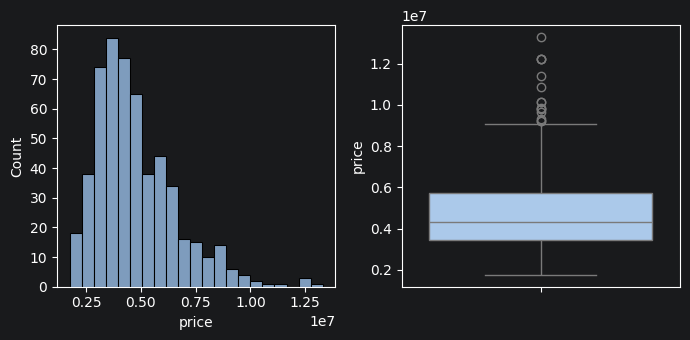

In [232]:
plt.rcParams["figure.figsize"] = [7.00, 3.50]  # 设置图形默认尺寸
plt.rcParams["figure.autolayout"] = True       # 自动调整图形布局
figure, axes = plt.subplots(1, 2)  # 创建1行2列的子图
sns.histplot(cleaned_house_price, x="price", ax=axes[0])  # 绘制房价直方图
sns.boxplot(cleaned_house_price, y="price", ax=axes[1])   # 绘制房价箱线图
plt.show()

住宅価格は右に歪んだ分布を示しており、データセット内の多くの住宅価格は中程度である一方、一部に非常に高い極端な値が存在し、平均値を押し上げていることを示している。

### 面積の分布

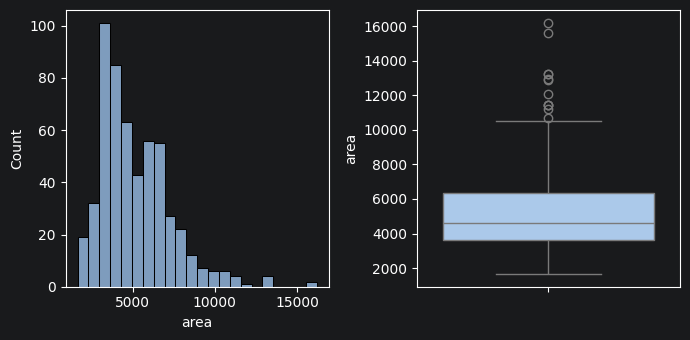

In [233]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='area', ax=axes[0])
sns.boxplot(cleaned_house_price, y='area', ax=axes[1])
plt.show()

面積の分布は住宅価格と似ており、右に歪んだ分布を示している。

### 住宅価格と面積の関係

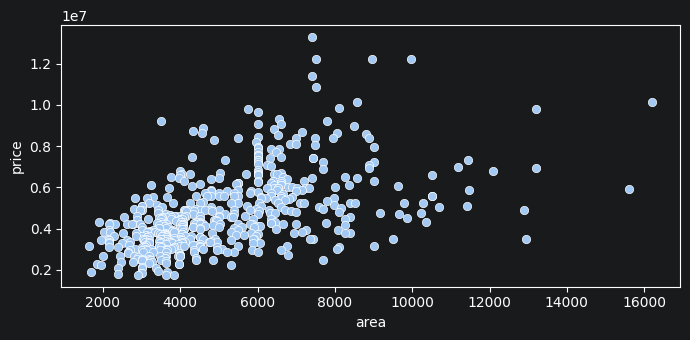

In [234]:
sns.scatterplot(cleaned_house_price, x='area', y='price')
plt.show()

散布図から、おおよその正の相関関係が確認できるが、関係の強さについては、後で相関係数を計算して確認する必要がある。

### 寝室数と住宅価格

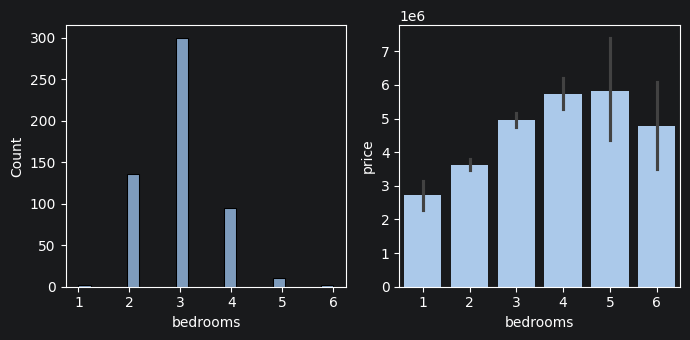

In [235]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bedrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bedrooms', y='price', ax=axes[1])
plt.show()

このデータセットにおける住宅の寝室数は1～6室であり、多くの住宅は2～4室となっている。

平均住宅価格と寝室数の棒グラフを見ると、寝室数が5室未満の場合は、寝室数が多い住宅ほど価格も高くなる傾向がある。しかし、5室を超えると、寝室数が増えても住宅価格が必ずしも高くなるとは限らない。

### バスルーム数と住宅価格

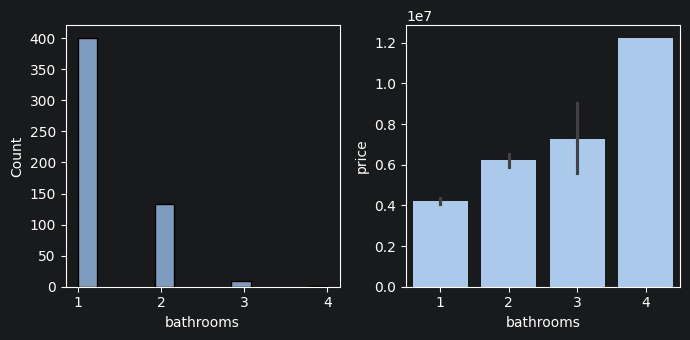

In [236]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bathrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bathrooms', y='price', ax=axes[1])
plt.show()

データセット内の住宅のバスルーム数は最少1室、最多4室であり、1室の住宅が最も多い。

平均住宅価格とバスルーム数の棒グラフを見ると、バスルーム数が多い住宅ほど価格も高くなる傾向がある。

### 階数と住宅価格

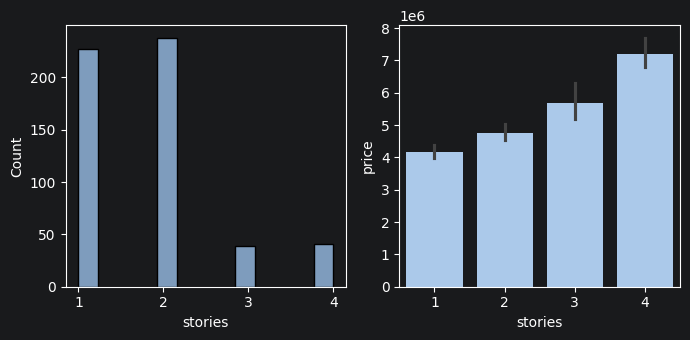

In [237]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='stories', ax=axes[0])
sns.barplot(cleaned_house_price, x='stories', y='price', ax=axes[1])
plt.show()

このデータセットにおける住宅の階数は1～4階であり、多くの住宅は1階または2階となっている。

平均住宅価格と階数の棒グラフを見ると、階数が多い住宅ほど価格も高くなる傾向がある。

### ガレージ数と住宅価格

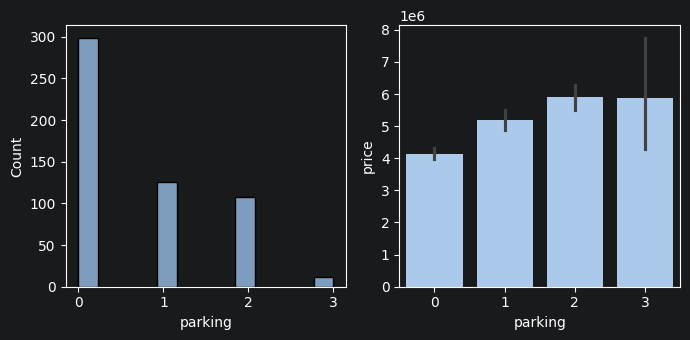

In [238]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='parking', ax=axes[0])
sns.barplot(cleaned_house_price, x='parking', y='price', ax=axes[1])
plt.show()

このデータセットにおける住宅のガレージ数は0～3台分であり、ガレージのない住宅が最も多く、次いで1台分、2台分の順となっている。

平均住宅価格とガレージ数の棒グラフを見ると、ガレージ数が多い住宅ほど価格も高くなる傾向があるが、2台分を超えると、ガレージ数が増えても住宅価格が必ずしも高くなるとは限らない。

### 幹線道路沿いかどうかと住宅価格

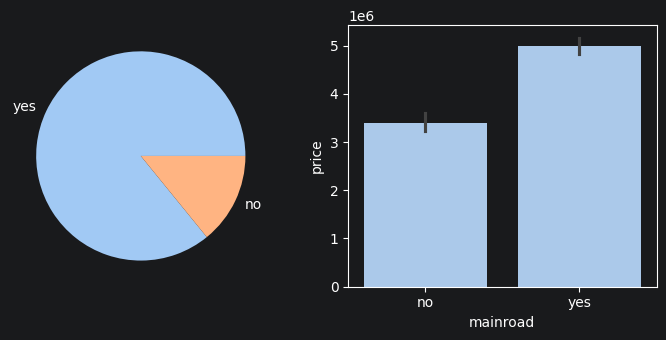

In [239]:
figure, axes = plt.subplots(1, 2)
mainroad_count = cleaned_house_price['mainroad'].value_counts()
mainroad_label = mainroad_count.index
axes[0].pie(mainroad_count, labels=mainroad_label)
sns.barplot(cleaned_house_price, x='mainroad', y='price', ax=axes[1])
plt.show()

このデータセットでは、多くの住宅が幹線道路沿いに位置している。

平均住宅価格と幹線道路沿いかどうかの棒グラフを見ると、幹線道路沿いにある住宅のほうが価格も高い傾向がある。

### ゲストルームの有無と住宅価格

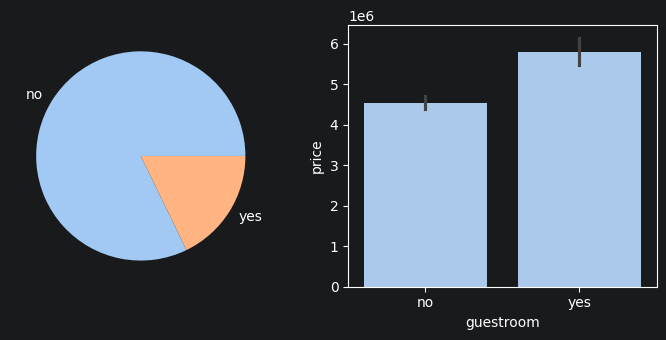

In [240]:
figure, axes = plt.subplots(1, 2)
guestroom_count = cleaned_house_price['guestroom'].value_counts()
guestroom_label = guestroom_count.index
axes[0].pie(guestroom_count, labels=guestroom_label)
sns.barplot(cleaned_house_price, x='guestroom', y='price', ax=axes[1])
plt.show()

このデータセットでは、ほとんどの住宅にゲストルームがない。

平均住宅価格とゲストルームの有無の棒グラフを見ると、ゲストルームがある住宅のほうが価格も高い傾向がある。

### 地下室の有無と住宅価格

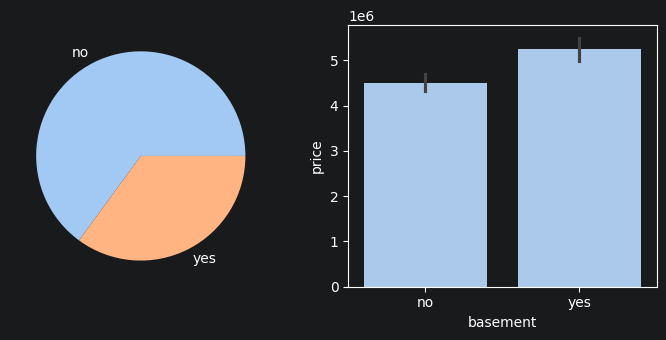

In [241]:
figure, axes = plt.subplots(1, 2)
basement_count = cleaned_house_price['basement'].value_counts()
basement_label = basement_count.index
axes[0].pie(basement_count, labels=basement_label)
sns.barplot(cleaned_house_price, x='basement', y='price', ax=axes[1])
plt.show()

このデータセットでは、地下室のない住宅のほうが多い。

平均住宅価格と地下室の有無の棒グラフを見ると、地下室がある住宅のほうが価格も高い傾向がある。

### 給湯設備の有無と住宅価格

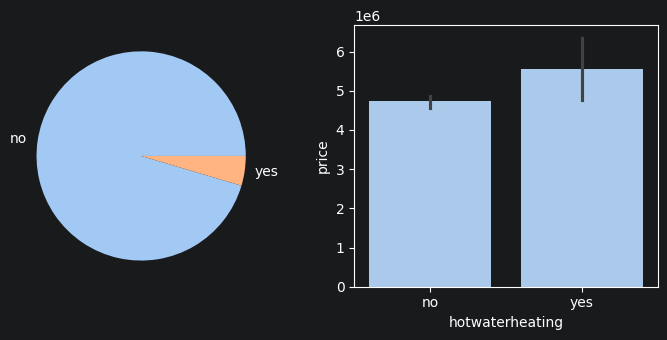

In [242]:
figure, axes = plt.subplots(1, 2)
hotwaterheating_count = cleaned_house_price['hotwaterheating'].value_counts()
hotwaterheating_label = hotwaterheating_count.index
axes[0].pie(hotwaterheating_count, labels=hotwaterheating_label)
sns.barplot(cleaned_house_price, x='hotwaterheating', y='price', ax=axes[1])
plt.show()

このデータセットでは、ほとんどの住宅に給湯設備がない。

平均住宅価格と給湯設備の有無の棒グラフを見ると、給湯設備がある住宅のほうが価格も高い傾向がある。

### エアコンの有無と住宅価格

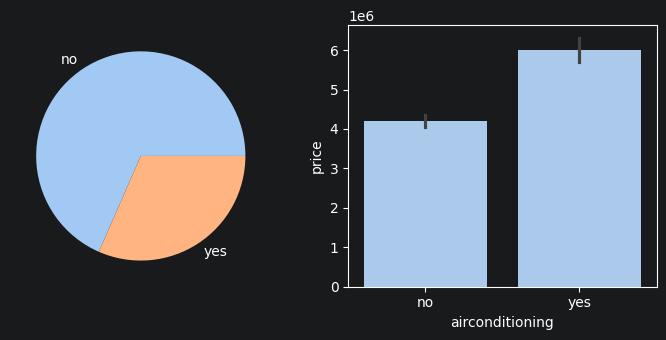

In [243]:
figure, axes = plt.subplots(1, 2)
airconditioning_count = cleaned_house_price['airconditioning'].value_counts()
airconditioning_label = hotwaterheating_count.index
axes[0].pie(airconditioning_count, labels=airconditioning_label)
sns.barplot(cleaned_house_price, x='airconditioning', y='price', ax=axes[1])
plt.show()

このデータセットでは、エアコンのない住宅のほうが多い。

平均住宅価格とエアコンの有無の棒グラフを見ると、エアコンがある住宅のほうが価格も高い傾向がある。

### 人気住宅街に位置するかどうかと住宅価格

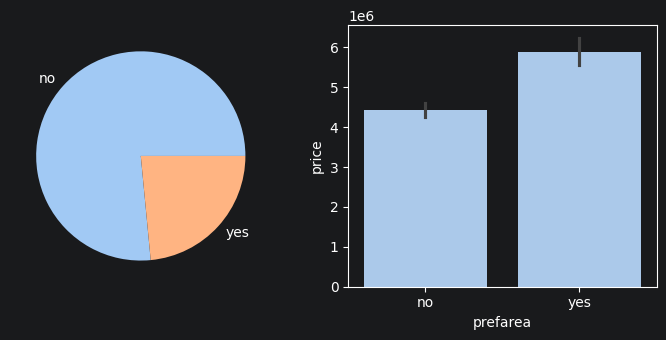

In [244]:
figure, axes = plt.subplots(1, 2)
prefarea_count = cleaned_house_price['prefarea'].value_counts()
prefarea_label = prefarea_count.index
axes[0].pie(prefarea_count, labels=prefarea_label)
sns.barplot(cleaned_house_price, x='prefarea', y='price', ax=axes[1])
plt.show()

このデータセットでは、ほとんどの住宅が人気住宅街に位置していない。

平均住宅価格と人気住宅街に位置するかどうかの棒グラフを見ると、人気住宅街にある住宅のほうが価格も高い傾向がある。

### 内装状態と住宅価格

C:\Users\tangy\AppData\Local\Temp\ipykernel_15680\2706727789.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')  # 将X轴标签旋转45度并右对齐


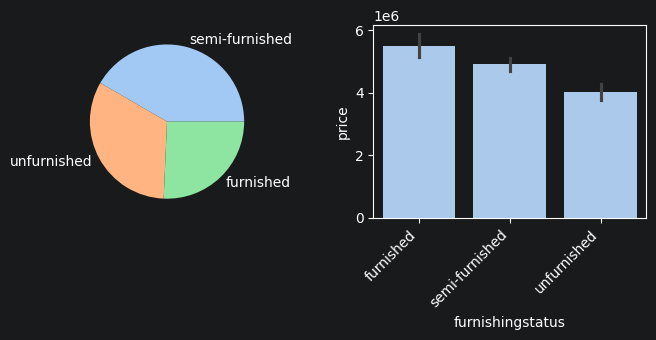

In [245]:
figure, axes = plt.subplots(1, 2)
furnishingstatus_count = cleaned_house_price['furnishingstatus'].value_counts()
furnishingstatus_label = furnishingstatus_count.index
axes[0].pie(furnishingstatus_count, labels=furnishingstatus_label)
sns.barplot(cleaned_house_price, x='furnishingstatus', y='price', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')  # 将X轴标签旋转45度并右对齐
plt.show()

このデータセットでは、簡易内装と未内装の住宅が多く、約4分の1の住宅が高級内装となっている。

平均住宅価格と内装状態の棒グラフを見ると、高級内装の住宅価格が簡易内装より高く、簡易内装の住宅価格は未内装より高い。

## データ分析

分析のステップでは、cleaned_house_priceのデータを使用して線形回帰分析を行い、住宅の各属性に基づいて価格を予測できる数理モデルの構築を目指す。

まず、線形回帰に必要なモジュールをインポートする。

次に、新しいDataFrameであるlr_house_priceを作成し、線形回帰分析に使用するデータとする。

cleaned_house_priceと分ける理由は、回帰分析を行う前に、ダミー変数の導入などのデータ準備が必要になる可能性があり、それらの処理をlr_house_price上で実行できるようにするためである。

In [246]:
import statsmodels.api as sm

In [247]:
lr_house_price = cleaned_house_price.copy()

データにはカテゴリ変数が含まれているため、そのままでは線形回帰モデルを構築できない。そこでダミー変数を導入し、そのカテゴリに該当するかどうかをそれぞれ0と1で表す。

In [248]:
lr_house_price = pd.get_dummies(lr_house_price, columns=["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"], dtype=int, drop_first=True)
lr_house_price

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


次に、目的変数と説明変数を分ける。

目的変数にはpriceを使用する。線形回帰を行う目的は、住宅価格に影響を与える可能性のあるほかの変数に基づいて、販売価格を予測できるモデルを構築することである。

In [249]:
y = lr_house_price["price"]

In [250]:
X = lr_house_price.drop("price", axis=1)

価格以外のすべての変数を説明変数に含めることができるが、変数間の相関関係を確認する必要がある。変数同士の相関が高い場合、多重共線性が発生する可能性がある。

一般に、相関係数の絶対値が0.8を超える場合、深刻な多重共線性が生じる可能性があるため、確認時には絶対値が0.8を超える値を抽出すればよい。

In [251]:
X.corr().abs() > 0.8

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,True,False,False,False,False,False,False,False,False,False,False,False,False
bedrooms,False,True,False,False,False,False,False,False,False,False,False,False,False
bathrooms,False,False,True,False,False,False,False,False,False,False,False,False,False
stories,False,False,False,True,False,False,False,False,False,False,False,False,False
parking,False,False,False,False,True,False,False,False,False,False,False,False,False
mainroad_yes,False,False,False,False,False,True,False,False,False,False,False,False,False
guestroom_yes,False,False,False,False,False,False,True,False,False,False,False,False,False
basement_yes,False,False,False,False,False,False,False,True,False,False,False,False,False
hotwaterheating_yes,False,False,False,False,False,False,False,False,True,False,False,False,False
airconditioning_yes,False,False,False,False,False,False,False,False,False,True,False,False,False


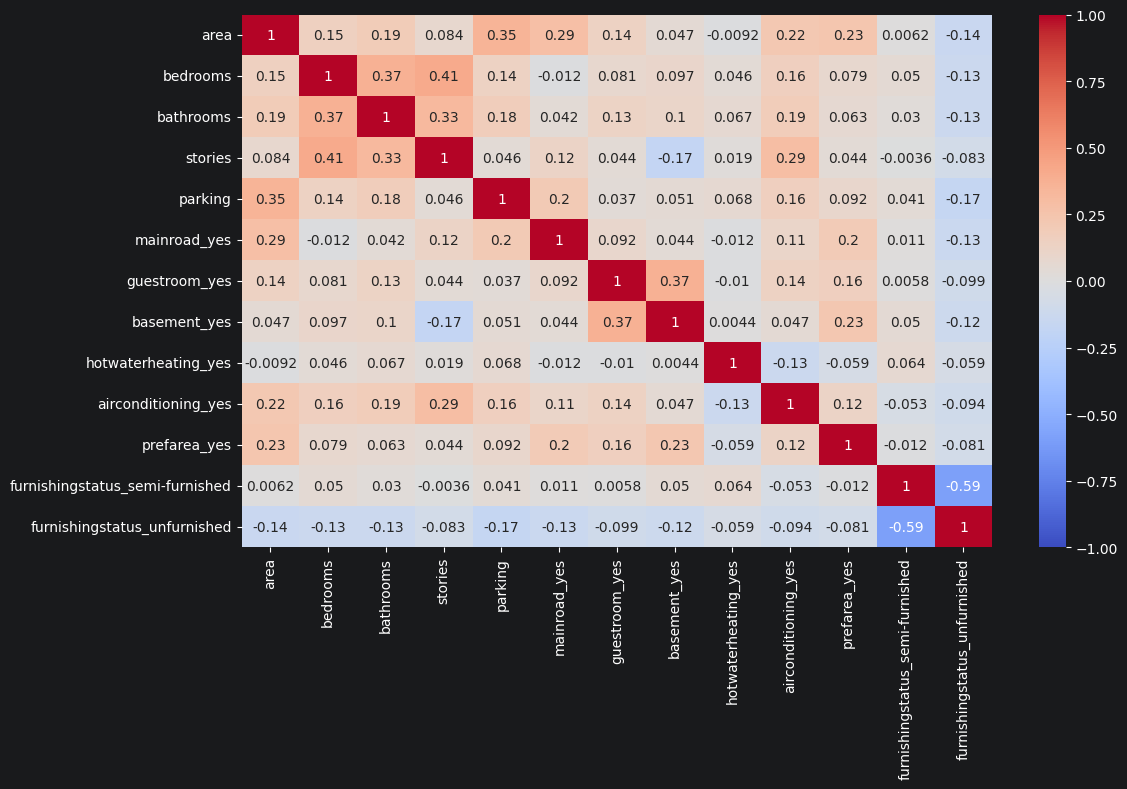

In [252]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

上記の出力から、異なる変数間の相関係数の絶対値は、すべて0.8以下であることが分かる。

次に、モデルの線形方程式に切片を追加する。

In [253]:
X = sm.add_constant(X)
X

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1.0,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0,0


OLS関数を呼び出し、最小二乗法を用いて線形回帰モデルのパラメータを推定する。さらに、summaryメソッドを使用して要約情報を取得する。

In [254]:
model = sm.OLS(y, X).fit()

In [255]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          9.07e-123
Time:                        21:48:44   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
mainroad_yes                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom_yes                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement_yes                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating_yes              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning_yes               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
prefarea_yes                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

有意水準を0.05に設定した場合、上記の結果のp値から、モデルでは以下の要因が住宅価格に有意な影響を与えていないと判断できる：寝室数、簡易内装であるかどうか。また、定数項（線形方程式の切片）のp値も大きく、有意な影響がないことを示している。

これらの変数を除外した後、線形回帰モデルを再構築する。

In [256]:
X = X.drop(["const", "bedrooms", "furnishingstatus_semi-furnished"], axis=1)

In [257]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):                        0.00
Time:                        21:48:45   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           257.5854     22.577     11.409      0.000     213.234     301.936
bathrooms                     1.071e+06   9.27e+04     11.553      0.000    8.89e+05    1.25e+06
stories                       5.084e+05   5.71e+04      8.898      0.000    3.96e+05    6.21e+05
parking                       2.793e+05   5.83e+04      4.794      0.000    1.65e+05    3.94e+05
mainroad_yes                  4.672e+05   1.27e+05      3.679      0.000    2.18e+05    7.17e+05
guestroom_yes                 2.851e+05   1.31e+05      2.172      0.030    2.72e+04    5.43e+05
basement_yes                  4.016e+05   1.07e+05      3.765      0.000    1.92e+05    6.11e+05
hotwaterheating_yes           8.668e+05   2.23e+05      3.884      0.000    4.28e+05    1.31e+06
airconditioning_yes           8.543e+05   1.07e+05      7.952      0.000    6.43e+05    1.07e+06
prefarea_yes                  6.443e+05   1.15e+05      5.594      0.000    4.18e+05    8.71e+05
furnishingstatus_unfurnished -3.493e+05   9.49e+04     -3.679      0.000   -5.36e+05   -1.63e+05
==============================================================================
Omnibus:                       94.840   Durbin-Watson:                   1.262
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              251.889
Skew:                           0.865   Prob(JB):                     2.01e-55
Kurtosis:                       5.845   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

p値の大きい説明変数を線形回帰モデルから除外すると、決定係数 R
2
 は0.682から0.957に上昇し、既存データに対するモデルの適合度が向上したことが分かる。

各説明変数の線形回帰方程式における係数を見ると、モデルでは以下の要因の増加、または存在によって住宅価格が有意に上昇すると予測される：住宅面積、トイレ数、階数、駐車可能台数、幹線道路沿いに位置すること、ゲストルームがあること、地下室があること、給湯設備があること、エアコンがあること、人気住宅街に位置すること。

一方、線形回帰モデルでは、住宅が未内装の状態であることによって、住宅価格が有意に低下すると予測される。

In [258]:
# 住宅価格を予測する住宅の情報：
# 面積は6,500平方フィート、寝室数は4、トイレ数は2、全2階、幹線道路沿いではない、ゲストルームなし、地下室あり、給湯設備あり、エアコンなし、駐車可能台数は2、人気住宅街に位置し、簡易内装である。

In [259]:
price_to_predict = pd.DataFrame({'area': [5600], 'bedrooms': [4], 'bathrooms': [2],
                                 'stories': [2], 'mainroad': ['no'], 'guestroom': ['no'],
                                 'basement': ['yes'], 'hotwaterheating': ['yes'],
                                 'airconditioning': ['no'], 'parking': 2, 'prefarea': ['yes'],
                                 'furnishingstatus': ['semi-furnished']})
price_to_predict

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,5600,4,2,2,no,no,yes,yes,no,2,yes,semi-furnished


カテゴリ変数のデータ型をCategoryに変換し、categoriesパラメータを使って、取り得るすべてのカテゴリ値をプログラムに指定する必要がある。

これは、予測用データにすべてのカテゴリが含まれているとは限らないためである。ダミー変数を作成する際に、一部のカテゴリに対応する変数が欠けないようにする必要がある。

In [260]:
price_to_predict['mainroad'] = pd.Categorical(price_to_predict['mainroad'], categories=['no', 'yes'])
price_to_predict['guestroom'] = pd.Categorical(price_to_predict['guestroom'], categories=['no', 'yes'])
price_to_predict['basement'] = pd.Categorical(price_to_predict['basement'], categories=['no', 'yes'])
price_to_predict['hotwaterheating'] = pd.Categorical(price_to_predict['hotwaterheating'], categories=['no', 'yes'])
price_to_predict['airconditioning'] = pd.Categorical(price_to_predict['airconditioning'], categories=['no', 'yes'])
price_to_predict['prefarea'] = pd.Categorical(price_to_predict['prefarea'], categories=['no', 'yes'])
price_to_predict['furnishingstatus'] = pd.Categorical(price_to_predict['furnishingstatus'], categories=['furnished', 'semi-furnished', 'unfurnished'])

次に、カテゴリ変数にダミー変数を導入する。

In [261]:
price_to_predict = pd.get_dummies(price_to_predict, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea', 'furnishingstatus'], dtype=int, drop_first=True)

In [262]:
price_to_predict

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,5600,4,2,2,2,0,0,1,1,0,1,1,0


In [263]:
price_to_predict = price_to_predict.drop(['bedrooms', 'furnishingstatus_semi-furnished'], axis=1)

次に、線形回帰モデルのpredictメソッドを呼び出し、予測価格を取得する。

In [264]:
predicted_value = model.predict(price_to_predict)
predicted_value

0    7.071927e+06
dtype: float64

線形回帰モデルによる予測価格は、7,071,927である。